In [2]:
## IMPORTS ##
####################################

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset, random_split
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

#scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# general
import numpy as np
import glob
import re
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import random

# imagery
# import tifffile as tiff
# from PIL import Image
# import rasterio

# hdf5
import h5py

# xarray
import xarray as xr

# geo
import geopandas as gpd



In [3]:
## ============================================================= ##
## COMPILE DATASET WITH LABEL INFORMATION FROM DUNMIRE AND RINES ##
## ============================================================= ##

# load Dunmire information
ds = xr.open_dataset("/home/jupyter/repos/lake-vision/sandbox/all_lakes_2019.nc")
ds = (
    ds
    .sel(ids=ds.ids.str.contains("CW"))
    .sortby("ids")
    .sel(time=slice("2019-05-01", "2019-09-30"))
)

# load label CSV and align
df = pd.read_csv("/home/jupyter/repos/lake-vision/sandbox/labels_ND_ED_LD_CD_2019CW.csv")
df = df.set_index("lakenum_dunmire").reindex(ds.ids.values)

# define class dimension
class_labels = ["ND", "ED", "LD", "CD"]
num_classes = len(class_labels)

# one-hot encode label_dunmire
label_dunmire = df["label_dunmire"].astype("Int64")
onehot = np.eye(num_classes)[label_dunmire.fillna(-1).astype(int)]
onehot[label_dunmire.isna()] = np.nan  # mask NaNs back

# create DataArray with (ids, class)
da_dunmire = xr.DataArray(
    onehot,
    dims=["ids", "class"],
    coords={
        "ids": ds.ids.values,
        "class": np.arange(num_classes)
    },
    name="label_dunmire"
)

# load rines probability vectors from .csv file
rines_probs = df[[f"prob_{i}_{cls}" for i, cls in enumerate(class_labels)]].values
da_rines = xr.DataArray(
    rines_probs,
    dims=["ids", "class"],
    coords={
        "ids": ds.ids.values,
        "class": np.arange(num_classes)
    },
    name="label_rines"
)

# load date_drainfreeze from .csv labels file
df["date_drainfreeze"] = pd.to_datetime(df["date_drainfreeze"].dropna().astype(int).astype(str), format="%Y%m%d")
da_drainfreeze = xr.DataArray(
    df["date_drainfreeze"].values,
    dims=["ids"],
    coords={"ids": ds.ids.values},
    name="date_drainfreeze"
)

# add date_drainfreeze_idx
t0 = pd.Timestamp("2019-05-01")
df["date_drainfreeze_idx"] = (df["date_drainfreeze"] - t0).dt.days
da_drainfreeze_idx = xr.DataArray(
    df["date_drainfreeze_idx"].values,
    dims=["ids"],
    coords={"ids": ds.ids.values},
    name="date_drainfreeze_idx"
)

# merge into final dataset
ds = ds.assign(label_dunmire=da_dunmire, label_rines=da_rines, date_drainfreeze=da_drainfreeze, date_drainfreeze_idx=da_drainfreeze_idx)

# forward- and back-fill all time-varying variables so there are no NaNs
time_vars = [v for v, da in ds.data_vars.items() if "time" in da.dims]
df_filled = (
    ds[time_vars]
      .to_dataframe()
      .groupby(level="ids")
      .ffill()
      .bfill()
)
ds_timefilled = df_filled.to_xarray()
ds = xr.merge([ds_timefilled, ds.drop_vars(time_vars)])

# add lakenum_rines as a coordinate along ids
ds = ds.assign_coords(lakenum_rines=("ids", df["lakenum_rines"].values))

# # limit to the first n lakes
# lakelim = 500
# ds = ds.isel(ids=slice(0,lakelim))




In [4]:
ds


<xarray.Dataset> Size: 11MB
Dimensions:               (ids: 1000, time: 153, class: 4)
Coordinates:
  * ids                   (ids) object 8kB 'CW2019_1524' ... 'CW2019_2523'
  * time                  (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
  * class                 (class) int64 32B 0 1 2 3
    lakenum_rines         (ids) object 8kB '2019cw_1' ... '2019cw_1000'
Data variables: (12/13)
    S1_image_id           (ids, time) object 1MB '' ... 'S1A_IW_GRDH_1SDH_201...
    S1_code               (ids, time) object 1MB '' '25-A-2' ... '127-A-2'
    HV_lake               (ids, time) float64 1MB -15.7 -15.7 ... -18.5 -18.64
    HV_out                (ids, time) float64 1MB -14.74 -14.74 ... -18.0 -18.27
    S2_water              (ids, time) float64 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S2_zenith             (ids, time) float64 1MB 53.52 53.52 ... 71.16 71.16
    ...                    ...
    LS_zenith             (ids, time) float64 1MB 52.81 52.81 ... 71.68 71.68
    t2m                   (ids, time) float64 1MB 270.8 271.9 ... 267.7 268.2
    label_dunmire         (ids, class) float64 32kB 1.0 0.0 0.0 ... 0.0 1.0 0.0
    label_rines           (ids, class) float64 32kB 0.9 0.1 0.0 ... 0.4 0.6 0.0
    date_drainfreeze      (ids) datetime64[ns] 8kB 2019-08-19 ... 2019-06-16
    date_drainfreeze_idx  (ids) int64 8kB 110 34 69 123 29 18 ... 34 68 54 28 46

In [5]:
## ========================================== ##
## SPLIT DS INTO TRAINING AND VALIDATION SETS ##
## ========================================== ##

# 1) get all the lake IDs
all_ids = ds.ids.values  # array of strings

# 2) randomly shuffle and split into train/val
rng = np.random.default_rng(42)
perm = rng.permutation(len(all_ids))
n_train = int(0.8 * len(all_ids))
train_ids = all_ids[perm[:n_train]]
val_ids   = all_ids[perm[n_train:]]

# 3) select two smaller xarray Datasets
ds_train = ds.sel(ids=train_ids)
ds_val   = ds.sel(ids=val_ids)

ds_train



<xarray.Dataset> Size: 9MB
Dimensions:               (ids: 800, time: 153, class: 4)
Coordinates:
  * ids                   (ids) object 6kB 'CW2019_2502' ... 'CW2019_1618'
  * time                  (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
  * class                 (class) int64 32B 0 1 2 3
    lakenum_rines         (ids) object 6kB '2019cw_979' ... '2019cw_95'
Data variables: (12/13)
    S1_image_id           (ids, time) object 979kB '' ... 'S1A_IW_GRDH_1SDH_2...
    S1_code               (ids, time) object 979kB '' '25-A-1' ... '' '127-A-3'
    HV_lake               (ids, time) float64 979kB -19.39 -19.39 ... -8.004
    HV_out                (ids, time) float64 979kB -21.23 -21.23 ... -9.469
    S2_water              (ids, time) float64 979kB 0.00657 0.5967 ... 0.02659
    S2_zenith             (ids, time) float64 979kB 56.76 56.2 ... 70.57 70.57
    ...                    ...
    LS_zenith             (ids, time) float64 979kB 57.09 57.09 ... 70.38 70.38
    t2m                   (ids, time) float64 979kB 272.0 272.0 ... 264.0 263.6
    label_dunmire         (ids, class) float64 26kB 0.0 0.0 1.0 ... 1.0 0.0 0.0
    label_rines           (ids, class) float64 26kB 0.0 0.0 0.0 ... 1.0 0.0 0.0
    date_drainfreeze      (ids) datetime64[ns] 6kB 2019-06-29 ... 2019-08-05
    date_drainfreeze_idx  (ids) int64 6kB 59 84 131 97 125 63 ... 47 38 62 29 96

In [6]:
ds_tstack = xr.open_dataset("/home/jupyter/data/tstacks/2019cw_tstacks/tstack_2019cw_366.nc")
desired_bands = ['B04', 'B03', 'B02', 'mask']
img_seq = ds_tstack['reflectance'].sel(band=desired_bands)

# plt.imshow(img_seq[1,3,:,:])
img_seq.shape


(153, 4, 512, 512)

In [7]:
## ==================== ##
## DEFINE DATASET CLASS ##
## ==================== ##

class DatasetS2VolCurve(Dataset):
    def __init__(self, dir_tstacks, ds_labels, seq_len=153, transform=None):
        self.dir_tstacks = dir_tstacks
        self.ds_labels = ds_labels
        self.seq_len = seq_len
        self.transform = transform
        
        # Map lake IDs (e.g., '2019cw_92') to filenames
        file_map = {
            re.search(r"tstack_(2019cw_\d+)\.nc", os.path.basename(fp)).group(1): fp
            for fp in glob.glob(os.path.join(dir_tstacks, "*.nc"))
        }

        # Only keep files that match entries in ds_labels
        self.files = [file_map[lake] for lake in ds_labels.lakenum_rines.values if lake in file_map]

        # Store other fields
        self.area_seqs = ds_labels.S2_water.values
        self.idx_max = ds_labels.S2_water.argmax(dim="time").values
        self.label_rines_vec = ds_labels.label_rines.values
        self.label_dunmire_vec = ds_labels.label_dunmire.values
        self.label_rines = np.argmax(self.label_rines_vec, axis=1)
        self.label_dunmire = np.argmax(self.label_dunmire_vec, axis=1)
        self.lakenums = ds_labels.lakenum_rines.values

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        
        lakenum_rines = self.ds_labels.lakenum_rines.values[idx]
        
        # load-in tstack as xarray dataset
        ds_tstack = xr.open_dataset(self.files[idx])

        # select only the desired bands (B04 = red, B03 = green, B02 = blue, 'mask' = mask)
        desired_bands = ['B04', 'B03', 'B02', 'mask']
        img_seq = ds_tstack['reflectance'].sel(band=desired_bands)  # shape: (time, band, y, x)
        
        # normalize the reflectance values
        img_seq[:,0:3,:,:] = img_seq[:,0:3,:,:] / 10000.0
        
        # pull out the date_drainfreeze
        date_drainfreeze_idx = self.ds_labels["date_drainfreeze_idx"][idx].values

        # Optional: center slicing around the disappearance date
        # Uncomment and use if needed
        center = int(date_drainfreeze_idx)
        half = self.seq_len // 2
        start = max(0, center - half)
        end = min(img_seq.shape[0], center + half + 1)
        if end - start < self.seq_len:
            if start == 0:
                end = min(self.seq_len, img_seq.shape[0])
            else:
                start = max(0, img_seq.shape[0] - self.seq_len)
        img_seq = img_seq[start:end]

        # pull area
        area = self.area_seqs[idx]        # (seq_len,)

        # pull label (both Rines and Dunmire)
        label_rines_vec = self.label_rines_vec[idx]
        label_dunmire_vec = self.label_dunmire_vec[idx]
        label_rines = self.label_rines[idx]
        label_dunmire = self.label_dunmire[idx]

        # to torch tensors
        img_seq = torch.tensor(img_seq.values, dtype=torch.float32)
        area = torch.tensor(area,   dtype=torch.float32).unsqueeze(-1)
        label_rines_vec = torch.tensor(label_rines_vec, dtype=torch.float32)
        label_dunmire_vec = torch.tensor(label_dunmire_vec, dtype=torch.float32)
        label_rines = torch.tensor(label_rines, dtype=torch.float32)
        label_dunmire = torch.tensor(label_dunmire, dtype=torch.float32)

        # transform
        if self.transform:
            img_seq = self.transform(img_seq)

        return img_seq, area, label_rines_vec, label_dunmire_vec, label_rines, label_dunmire, lakenum_rines
    
    

In [8]:
## ======================== ##
## EXAMPLE BATCH GENERATION ##
## ======================== ##

dir_tstacks = "/home/jupyter/data/tstacks/2019cw_tstacks/"

# ds must already exist from  previous steps
test_ds   = DatasetS2VolCurve(dir_tstacks, ds, seq_len=51)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=True)

# grab one batch
img_batch, area_batch, label_batch_rines_vec, label_batch_dunmire_vec, label_batch_rines, label_batch_dunmire, lakenum_batch = next(iter(test_loader))

print(f"img_batch.shape: {img_batch.shape}")     # e.g. (4, 21, C, H, W)
print(f"area_batch.shape: {area_batch.shape}")    # (4, 21, 1)
print(f"label_batch_rines_vec: {label_batch_rines_vec}")         # tensor([...])
print(f"label_batch_dunmire_vec: {label_batch_dunmire_vec}")         # tensor([...])
print(f"label_batch_rines: {label_batch_rines}")         # tensor([...])
print(f"label_batch_dunmire: {label_batch_dunmire}")         # tensor([...])
print(f"lakenum_batch: {lakenum_batch}")       # list of 4 strings



img_batch.shape: torch.Size([2, 51, 4, 512, 512])
area_batch.shape: torch.Size([2, 153, 1])
label_batch_rines_vec: tensor([[0., 0., 0., 1.],
        [1., 0., 0., 0.]])
label_batch_dunmire_vec: tensor([[0., 1., 0., 0.],
        [0., 0., 0., 1.]])
label_batch_rines: tensor([3., 0.])
label_batch_dunmire: tensor([1., 3.])
lakenum_batch: ('2019cw_30', '2019cw_87')


In [9]:
## ================================================== ##
## INSTANTIATE DATASET OBJECTS (FULL, TRAIN, AND VAL) ##
## ================================================== ##

dir_tstacks = "/home/jupyter/data/tstacks/2019cw_tstacks/"


full_dataset = DatasetS2VolCurve(dir_tstacks, ds, seq_len=153, transform=None)

train_dataset = DatasetS2VolCurve(dir_tstacks, ds_train, seq_len=51, transform=None)

val_dataset = DatasetS2VolCurve(dir_tstacks, ds_val, seq_len=51, transform=None)



In [28]:
## ====================================== ##
## CREATE DATALOADERS (TRAIN AND VAL) ##
## ====================================== ##

dl_train = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=4,
)

dl_val = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=4,
)



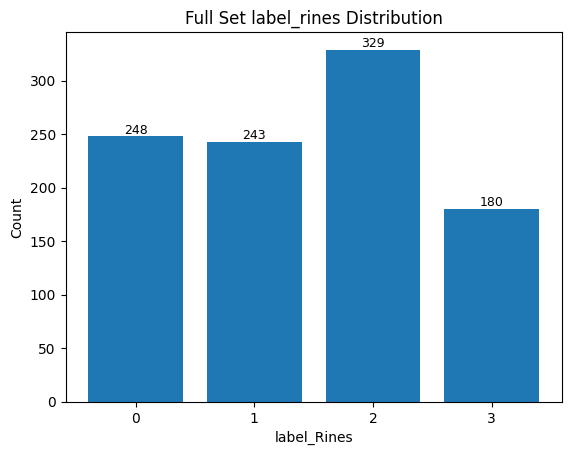

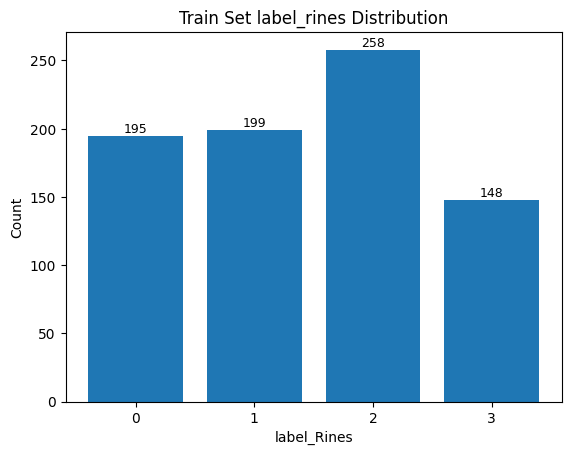

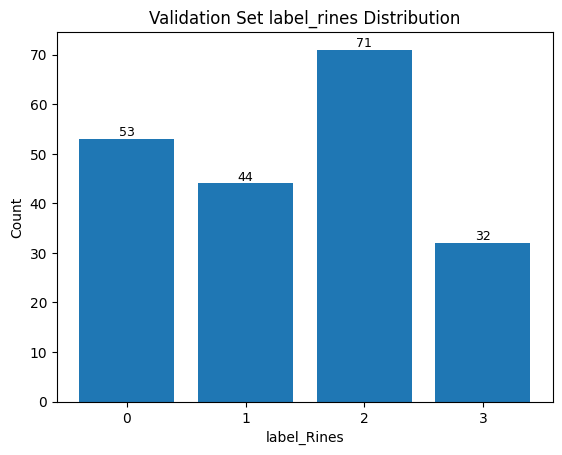

In [11]:
## =============================================================== ##
## PLOT DISTRIBUTIONS OF LABELS IN EACH DATASET (FULL, TRAIN, VAL) ##
## =============================================================== ##

# Extract labels
labels_full  = full_dataset.label_rines
labels_train = train_dataset.label_rines
labels_val   = val_dataset.label_rines

# Determine bins
classes = np.unique(np.concatenate([labels_train, labels_val]))
bins = np.arange(classes.min(), classes.max() + 2) - 0.5

def plot_with_counts(data, title):
    fig, ax = plt.subplots()
    counts, edges, patches = ax.hist(data, bins=bins, rwidth=0.8)
    ax.set_xticks(classes)
    ax.set_xlabel('label_Rines')
    ax.set_ylabel('Count')
    ax.set_title(title)

    # annotate each bar
    for count, patch in zip(counts, patches):
        if count > 0:
            x = patch.get_x() + patch.get_width() / 2
            y = count
            ax.text(x, y, str(int(count)), 
                    ha='center', va='bottom', fontsize=9)

    plt.show()

# Plot all three
plot_with_counts(labels_full,  'Full Set label_rines Distribution')
plot_with_counts(labels_train, 'Train Set label_rines Distribution')
plot_with_counts(labels_val,   'Validation Set label_rines Distribution')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1e-04..1.2472].


Lake 2019cw_979 — sequence length 51, channels 4, size 512×512


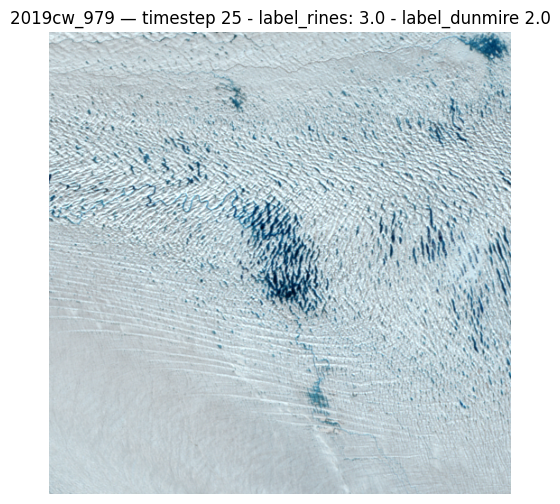

In [12]:
## ====================================== ##
## VISUALIZE ONE EXAMPLE FROM THE DATASET ##
## ====================================== ##

# 1) pull one example from the dataset
#    you can also do: batch = next(iter(train_loader)); img_seq, area, … = batch
img_seq, area, _, _, label_rines, label_dunmire, lakenum = train_dataset[0]

# img_seq is a tensor of shape (seq_len, C, H, W)
seq_len, C, H, W = img_seq.shape
print(f"Lake {lakenum} — sequence length {seq_len}, channels {C}, size {H}×{W}")

# 2) pick a time index to visualize
t = seq_len // 2  # middle of the sequence

# 3) select that frame, convert to H×W×C numpy
frame = img_seq[t]                 # (C, H, W)
frame_np = frame.permute(1, 2, 0).numpy()  # (H, W, C)

# 4) if your first 3 channels are R, G, B you can display an RGB:
plt.figure(figsize=(6,6))
plt.imshow(frame_np[..., :3])  # drop extra channels if >3
plt.title(f"{lakenum} — timestep {t} - label_rines: {label_rines} - label_dunmire {label_dunmire}")
plt.axis("off")
plt.show()



In [ ]:
## ======================================= ##
## BUILD THE ConvLSTM MODEL BLOCK BY BLOCK ##
## ======================================= ##

# SHALLOW CNN BLOCK:
class ShallowCNN(nn.Module):
    def __init__(self, in_channels=4, out_channels=8, num_layers=1):
        super(ShallowCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
            nn.LeakyReLU(inplace=True), # can replace with ReLU or GELU
            nn.MaxPool2d(kernel_size=2) # downsample: 512x512 -> 256x256
        )
        
    def forward(self,x):
        """
        Args:
            x: tensor of shape [B,T,4,512,512]
        Returns:
            tensor of shape [B,T,8,256,256]
        """
        B, T, C, H, W = x.shape
        x = x.reshape(B*T, C, H, W) # merge batch and time -> [B*T, 4, 512, 512]
        x = self.conv_block(x) # apply convolution and pooling -> [B*T, 8, 256, 256]
        _, C_out, H_out, W_out = x.shape
        x = x.reshape(B, T, C_out, H_out, W_out) # un-merge batch and time -> [B, T, 8, 256, 256]
        
        return x


# SPATIAL ATTENTION BLOCK (adapted from CBAM without channel attention)
class SpatialAttention(nn.Module):
    def __init__(self, in_channels, kernel_size=7):
        super(SpatialAttention, self).__init__()
        # spatial attention via average and max pooling across channels
        self.conv = nn.Conv2d(2,1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self,x):
        B, T, C, H, W = x.shape
        
        # flatten time into batch -> [B*T, C, H, W]
        x = x.reshape(B*T, C, H, W)
        
        # compute spatial attention map using max and average pooling across channels
        avg_pool = torch.mean(x, dim=1, keepdim=True) # -> [B*T, 1, H, W]
        max_pool, _ = torch.max(x, dim=1, keepdim=True) # -> [B*T, 1, H, W]
        attention_input = torch.cat([avg_pool, max_pool], dim=1) # [B*T, 2, H, W]
        
        attention_map = self.sigmoid(self.conv(attention_input)) # -> [B*T, 1, H, W]
        
        # apply attention map to input feature map:
        x = x*attention_map # -> [B*T, C, H, W]
        
        # reshape separating batch and time
        x = x.reshape(B, T, C, H, W) # -> [B, T, C, H, W]
        
        return x
    
        
# CONVOLUTIONAL LSTM (ConvLSTM) CELL:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super(ConvLSTMCell, self).__init__()
        padding = kernel_size // 2
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels
        
        self.conv = nn.Conv2d(
            in_channels=input_channels+hidden_channels,
            out_channels=4*hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )
        
    def forward(self, x, h_prev, c_prev):
        """
        x: [B, C_in, H, W]
        h_prev: [B, C_hidden, H, W]
        c_prev: [B, C_hidden, H, W]
        """
        combined = torch.cat([x, h_prev], dim=1) # [B, C_in+C_hidden
        gates = self.conv(combined)              # [B, 4*C_hidden, H, W]
        i, f, o, g = torch.chunk(gates, 4, dim=1) # gate splits
        
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        
        c = f*c_prev + i*g
        h = o*torch.tanh(c)
        
        return h, c
    
    
# ConvLSTM BLOCK (PROCESSING SEQUENCE):
class ConvLSTM(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super(ConvLSTM, self).__init__()
        self.cell = ConvLSTMCell(input_channels, hidden_channels, kernel_size)
        
    def forward(self, x):
        """
        x: [B, T, C_in, H, W]
        returns: h_seq [B, T, C_hidden, H, W]
        """
        
        B, T, _, H, W = x.shape
        h, c = self.init_hidden(B, H, W, self.cell.hidden_channels, x.device)
        
        outputs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outputs.append(h)
            
        h_seq = torch.stack(outputs, dim=1) # [B, T, C_hidden, H, W]
        
        return h_seq
    
    def init_hidden(self, B, H, W, C, device):
        return(
            torch.zeros(B, C, H, W, device=device),
            torch.zeros(B, C, H, W, device=device)
        )


# TEMPORAL ATTENTION BLOCK:
class TemporalAttention(nn.Module):
    def __init__(self, input_channels, hidden_dim=32, use_area=False):
        super(TemporalAttention, self).__init__()
        self.use_area = use_area
        attn_in_dim = input_channels + 1 if self.use_area else input_channels
        self.attn_mlp = nn.Sequential(
            nn.Linear(attn_in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1) # scalar attention score per timestep
        )
        
    def forward(self, x, area_seq=None):
        """
        x: [B, T, C, H, W]
        area_seq: [B, T, 1]
        returns: [B, C, H, W], attention-weighted sum over T
        """
        B, T, C, H, W = x.shape
        
        # global average pooling per timestep -> [B, T, C]
        x_gap = x.mean(dim=[3,4])
        
        # if using area_seq:
        if self.use_area and area_seq is not None:
            x_gap = torch.cat([x_gap, area_seq], dim=2) # concatenate area_seq as a channel, shape now [B, T, C+1]
        
        # MLP to get attention scores
        attn_scores = self.attn_mlp(x_gap) # -> [B, T, 1]
        
        # normalize with softmax across time
        attn_weights = torch.softmax(attn_scores, dim=1) # [B, T, 1]
        
        # weighted sum of original x over time
        attn_weights = attn_weights.unsqueeze(-1).unsqueeze(-1) # shape [B, T, 1, 1, 1]
        x_weighted = (x * attn_weights).sum(dim=1) # shape [B, C, H, W]
        
        return x_weighted
        
        
# CLASSIFICATION HEAD
class ClassificationHead(nn.Module):
    def __init__(self, input_channels, input_H, input_W, hidden_dim=64, num_classes=4):
        super(ClassificationHead, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(input_channels*input_H*input_W, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self,x):
        """
        x: [B, C, H, W]
        returns: [B, num_classes]
        """
        x = self.flatten(x) # [B, C*H*W]
        x = self.fc(x) # [B, num_classes]
        
        return x


        
    


In [ ]:
## ====================================== ##
## CONSTRUCT FULL MODEL FROM BLOCKS ABOVE ##
## ====================================== ##

class ConvLSTMClassifier(nn.Module):
    def __init__(self,
                 num_classes=4,
                 input_channels=4,
                 shallowcnn_out_channels=8,
                 lstm1_hidden=16,
                 lstm2_hidden=32,
                 input_H=512,
                 input_W=512,
                 use_area=False):
        super(ConvLSTMClassifier, self).__init__()
        self.use_area = use_area

        # (1) SHALLOW CNN: [B, T=153, C=4, 512, 512] --> [B, T=153, C=8, H=256, W=256]
        self.shallowcnn = ShallowCNN(in_channels=input_channels, out_channels=shallowcnn_out_channels)

        # (2) SPATIAL ATTENTION: shape remains the same [B, T=153, C=8, H=256, W=256]
        self.spatial_attn1 = SpatialAttention(in_channels=shallowcnn_out_channels)

        # (3) ConvLSTM BLOCK 1: [B, T=153, C=8, H=256, W=256] --> [B, T=153, C=16, H=256, W=256]
        self.convlstm1 = ConvLSTM(input_channels=shallowcnn_out_channels, hidden_channels=lstm1_hidden)

        # (4) POOLING: [B, T=153, C=16, H=256, W=256] --> [B, T=153, C=16, H=128, W=128]
        self.pool1 = nn.MaxPool3d(kernel_size=(1,2,2)) # pool over H and W but not T

        # (5) SPATIAL ATTENTION: shape remains the same [B, T=153, C=16, H=128, W=128]
        self.spatial_attn2 = SpatialAttention(in_channels=lstm1_hidden)

        # (6) ConvLSTM BLOCK 2: [B, T=153, C=16, H=128, W=128] --> [B, T=153, C=32, H=128, W=128]
        self.convlstm2 = ConvLSTM(input_channels=lstm1_hidden, hidden_channels=lstm2_hidden)

        # (7) POOLING: [B, T=153, C=32, H=128, W=128] --> [B, T=153, C=32, H=64, W=64]
        self.pool2 = nn.MaxPool3d(kernel_size=(1,2,2)) # pool over H and W but not T

        # (8) TEMPORAL ATTENTION: [B, T=153, C=32, H=64, W=64] --> [B, C=32, H=64, W=64]
        self.temporal_attn = TemporalAttention(input_channels=lstm2_hidden, use_area=self.use_area)

        # (9) CLASSIFICATION HEAD:
        self.classifier = ClassificationHead(
            input_channels=lstm2_hidden,
            input_H=input_H//8, # downsampled (pooled) three times (2**3=8)
            input_W=input_W//8,
            num_classes=num_classes,
        )
            
    
    # FORWARD METHOD:
    def forward(self, x, area_seq):
        """
        Args:
            x: tensor of shape [B, T=153, C=4, 512, 512]
            area_seq: tensor of shape [B, T=153, 1]
        returns:
            logits: tensor of shape [B, num_classes]
        """
        # (1) SHALLOW CNN
        x = self.shallowcnn(x)        # -> [B, T, 8, H=256, W=256]
        
        # (2) SPATIAL ATTENTION
        x = self.spatial_attn1(x)     # -> [B, T, 8, H=256, W=256]
        
        # (3) ConvLSTM BLOCK 1
        x = self.convlstm1(x)         # -> [B, T, 16, H=256, W=256]
        
        # (4) SPATIAL POOLING
        x = x.permute(0,2,1,3,4)      # -> [B, C=16, T, H=256, W=256]
        x = self.pool1(x)             # -> [B, C=16, T, H=128, W=128]
        x = x.permute(0,2,1,3,4)      # -> [B, T, C=16, H=128, W=128]
        
        # (5) SPATIAL ATTENTION
        x = self.spatial_attn2(x)     # -> [B, T, C=16, H=128, W=128]
        
        # (6) ConvLSTM BLOCK 2
        x = self.convlstm2(x)         # -> [B, T, C=32, H=128, W=128]
        
        # (7) SPATIAL POOLING
        x = x.permute(0,2,1,3,4)      # -> [B, C=32, T, H=128, W=128]
        x = self.pool2(x)             # -> [B, C=32, T, H=64, W=64]
        x = x.permute(0,2,1,3,4)      # -> [B, T, C=32, H=64, W=64]
        
        # (8) TEMPORAL ATTENTION
        x = self.temporal_attn(x, area_seq if self.use_area else None)     # -> [B, 32, 64, 64]
        
        # (9) CLASSIFICATION
        out = self.classifier(x)      # -> [B, num_classes]
        
        return out
    
    

In [49]:
######################
## TEST DUMMY INPUT ##
######################

model = ConvLSTMClassifier(use_area=True)

dummy_input = torch.randn(2, 153, 4, 512, 512)       # imagery
dummy_area_seq = torch.randn(2, 153, 1)              # dummy scalar area curve

with torch.no_grad():  # no need to compute gradients
    output = model(dummy_input, dummy_area_seq)
print(output.shape)



torch.Size([2, 4])


In [50]:
##########################
## INITIALIZE THE MODEL ##
##########################

model = ConvLSTMClassifier(use_area=False)



In [51]:
#######################
## MOVE MODEL TO GPU ##
#######################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"device: {device}")


device: cuda


In [52]:
###############################
## DEFINE LOSS AND OPTIMIZER ##
###############################

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [53]:
##################################################
## SET RANDOM SEED TO FIX WEIGHT INITIALIZATION ##
##################################################

def set_seed(seed=42):
    random.seed(seed)                # Python
    np.random.seed(seed)             # NumPy
    torch.manual_seed(seed)          # CPU
    torch.cuda.manual_seed(seed)     # GPU
    torch.cuda.manual_seed_all(seed) # all GPUs

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

# call function to set fixed random seed
set_seed(42)



In [30]:
###################
## TRAINING LOOP ##
###################

# clear GPU memory:
torch.cuda.empty_cache()

# start the clock:
t_start = time.time()

num_epochs = 1
for epoch in range(num_epochs):
    print(f"epoch {epoch}")
    
    # TRAINING PHASE:
    running_loss_train = 0.0
    model.train()
    for idx_batch, (img_batch, area_batch, label_batch_rines_vec, label_batch_dunmire_vec, label_batch_rines, label_batch_dunmire, lakenum_batch) in enumerate(dl_train):
        # print(f"\tBatch {idx_batch+1}/{len(dl_train)}")
        
        # move data to device:
        img_batch = img_batch.float().to(device)
        labels = label_batch_rines.long().to(device)
        
        # zero the parameter gradients:
        optimizer.zero_grad()
        
        # forward pass:
        # print(torch.cuda.memory_summary(device=torch.device("cuda"), abbreviated=False))
        logits = model(img_batch, area_batch)
        # print(torch.cuda.memory_summary(device=torch.device("cuda"), abbreviated=False))
        
        # compute loss:
        loss = criterion(logits, labels)
        
        # backward pass:
        loss.backward()
        
        # optimize model params:
        optimizer.step()
        
        # accumulate loss
        running_loss_train += loss.item()
        
        # apply softmax to get probabilities for each class
        probs = torch.softmax(logits, dim=1)
        
    # # clear memory after each epoch
    # torch.cuda.empty_cache()  # Release cached memory
    # gc.collect()  # Run garbage collection
    
    # time epoch
    t_epoch = time.time() - t_start

    # Print after epoch
    print(
        f"Epoch [{epoch}/{num_epochs-1}]; Elapsed: {t_epoch/60:.3f} min\n"
        f"\tLOSS: Train: {running_loss_train/len(dl_train):.4f}\n"
    )
        
        



epoch 0


KeyboardInterrupt: 

In [ ]:
# ## FULL TRAINING LOOP: ##
# #########################

# # loss, and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# # optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # use this for l2 regularization
# num_epochs = 100  # Set your desired number of epochs

# # set whether or not the output and error messages should be sent to other files
# redirect_output_to_files = False # redirect files to output and error logs (True/False)
# if redirect_output_to_files:
#     filepath_outputs = '/home/jupyter/lakes/AGU24/logs/augmented/LSTM_timeseq/file_outs_LSTMtimeseq.out'
#     filepath_errors = '/home/jupyter/lakes/AGU24/logs/augmented/LSTM_timeseq/file_errs_LSTMtimeseq.err'
#     print(f"outputs going to {filepath_outputs}")
#     print(f"errors going to {filepath_errors}")
#     # Open files for output and error
#     sys.stdout = open(filepath_outputs, 'w')
#     sys.stderr = open(filepath_errors, 'w')

# try:
#     print(f"TRAINING STARTED: {num_epochs} epochs planned \n")


#     # initialize collection lists for preds, labels, losses, and probabilities
#     preds_train, labels_train, losses_train, probs_train = [], [], [], []
#     preds_val, labels_val, losses_val, probs_val = [], [], [], []

#     # start the clock:
#     t_start = time.time()

#     # TRAINING LOOP:
#     for epoch in range(num_epochs):
#         print(f"epoch {epoch}")

#         # TRAINING PHASE: 
#         model.train()  # Set model to training mode
#         running_loss_train = 0.0
#         epoch_preds_train = []
#         epoch_labels_train = []
#         epoch_probs_train = []
#         for img_seqs, area_seqs, labelsR, labelsD, lakenums in dl_train:
#             # print(f"batch")
#             # Move data to the device
#             img_seqs = img_seqs.float().to(device)
#             labels = labelsR.long().to(device)

#             # Zero the parameter gradients
#             optimizer.zero_grad()

#             # Forward pass
#             logits = model(img_seqs, area_seqs)

#             # Compute loss
#             loss = criterion(logits, labels)

#             # Backward pass and optimize
#             loss.backward()
            
#             # # Inspect gradients
#             # for name, param in model.named_parameters():
#             #     if param.grad is not None:
#             #         grad_norm = param.grad.data.norm(2).item()
#             #         print(f"Layer: {name} | Gradient Norm: {grad_norm:.6f}")
#             #     else:
#             #         print(f"Layer: {name} | Gradient is None")
                    
#             # Optimize the model parameters
#             optimizer.step()

#             # Accumulate loss
#             running_loss_train += loss.item()

#             # Apply softmax to get probabilities for each class
#             probs = torch.softmax(logits, dim=1)

#             # Collect predictions, labels, and probabilities
#             predicted_classes = torch.argmax(logits, dim=1)  # Get class indices with highest score
#             epoch_preds_train.extend(predicted_classes.detach().cpu().numpy())
#             epoch_labels_train.extend(labels.detach().cpu().numpy())
#             epoch_probs_train.extend(probs.detach().cpu().numpy()) 

#         # Calculate training accuracy
#         epoch_preds_train = np.array(epoch_preds_train)
#         epoch_labels_train = np.array(epoch_labels_train)
#         train_accuracy = (epoch_preds_train == epoch_labels_train).mean()
        
#         # Calculate metrics for training
#         train_precision = precision_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)
#         train_recall = recall_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)
#         train_f1 = f1_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)

#         # At the end of each epoch, add epoch_preds, epoch_labels, and epoch_probs to the lists
#         preds_train.append(epoch_preds_train)
#         labels_train.append(epoch_labels_train)
#         probs_train.append(epoch_probs_train)
#         losses_train.append(running_loss_train / len(dl_train))

#         # VALIDATION PHASE:
#         model.eval()  # Set the model to evaluation mode
#         running_loss_val = 0.0
#         epoch_preds_val = []
#         epoch_labels_val = []
#         epoch_probs_val = []
#         with torch.no_grad():
#             for img_seqs, area_seqs, labelsR, labelsD, lakenums in dl_val:
#                 img_seqs = img_seqs.float().to(device)
#                 labels = labelsR.long().to(device)

#                 # forward pass
#                 logits = model(img_seqs, area_seqs)

#                 # compute and accumulate loss
#                 loss = criterion(logits, labels)
#                 running_loss_val += loss.item()

#                 # Apply softmax to get probabilities for each class
#                 probs = torch.softmax(logits, dim=1)

#                 # Collect predictions, labels, and probabilities
#                 predicted_classes = torch.argmax(logits, dim=1)  # Get class indices with highest score
#                 epoch_preds_val.extend(predicted_classes.detach().cpu().numpy())
#                 epoch_labels_val.extend(labels.detach().cpu().numpy())
#                 epoch_probs_val.extend(probs.detach().cpu().numpy())
                
#                 # Calculate distribution of predictions and labels using numpy
#                 unique_preds_train, pred_counts_train = np.unique(epoch_preds_train, return_counts=True)
#                 unique_labels_train, label_counts_train = np.unique(epoch_labels_train, return_counts=True)

#         # Calculate validation accuracy
#         epoch_preds_val = np.array(epoch_preds_val)
#         epoch_labels_val = np.array(epoch_labels_val)
#         val_accuracy = (epoch_preds_val == epoch_labels_val).mean()
        
#         # Calculate metrics for validation
#         val_precision = precision_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
#         val_recall = recall_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
#         val_f1 = f1_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
        
#         # Calculate distribution of predictions and labels using numpy
#         unique_preds_val, pred_counts_val = np.unique(epoch_preds_val, return_counts=True)
#         unique_labels_val, label_counts_val = np.unique(epoch_labels_val, return_counts=True)

#         # Append validation data to the lists
#         preds_val.append(epoch_preds_val)
#         labels_val.append(epoch_labels_val)
#         probs_val.append(epoch_probs_val)
#         losses_val.append(running_loss_val / len(dl_val))

#         # clear memory after each epoch
#         torch.cuda.empty_cache()  # Release cached memory
#         gc.collect()  # Run garbage collection

#         t_epoch = time.time() - t_start

#         # Print after epoch
#         print(
#             f"Epoch [{epoch}/{num_epochs-1}]; Elapsed: {t_epoch/60:.3f} min\n"
#             f"\tLOSS: Train: {running_loss_train/len(dl_train):.4f}; Val: {running_loss_val/len(dl_val):.4f} //\n"
#             f"\tACC:  Train: {train_accuracy:.4f}; Val: {val_accuracy:.4f} //\n"
#             f"\tPREC: Train: {train_precision:.4f}; Val: {val_precision:.4f} //\n"
#             f"\tREC:  Train: {train_recall:.4f}; Val: {val_recall:.4f} //\n"
#             f"\tF1:   Train: {train_f1:.4f}; Val: {val_f1:.4f} //\n"
#             f"\tPredicted Counts Train: "
#             f"{ {int(k): int(v) for k, v in zip(unique_preds_train, pred_counts_train)} }; "
#             f"Label Counts Train: "
#             f"{ {int(k): int(v) for k, v in zip(unique_labels_train, label_counts_train)} } //\n"
#             f"\tPredicted Counts Val:   "
#             f"{ {int(k): int(v) for k, v in zip(unique_preds_val, pred_counts_val)} }; "
#             f"Label Counts Val:   "
#             f"{ {int(k): int(v) for k, v in zip(unique_labels_val, label_counts_val)} }"
#         )
    
#         # Save model weights every 10 epochs
#         if (epoch) % 10 == 0 or (epoch)==num_epochs-1:
#             torch.save(model.state_dict(), f"/home/jupyter/repos/lake-vision/sandbox/weights/lstm_drainTYPE_{epoch}.pth")

#             # Save losses, predictions, and labels
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/losses_train_epoch_{epoch}.npy", losses_train)
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/losses_val_epoch_{epoch}.npy", losses_val)
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/preds_train_epoch_{epoch}.npy", preds_train)
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/preds_val_epoch_{epoch}.npy", preds_val)
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/labels_train_epoch_{epoch}.npy", labels_train)
#             np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/labels_val_epoch_{epoch}.npy", labels_val)
    
# except Exception as e:
#     print(f"An error occurred: {e}", file=sys.stderr)  # Will go to 'error.log' or terminal
# print("TRAINING COMPLETE.")    
    
    

TRAINING STARTED: 100 epochs planned 

epoch 0
Epoch [0/99]; Elapsed: 6.431 min
	LOSS: Train: 0.9157; Val: 0.9026 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150 //
	F1:   Train: 0.4730; Val: 0.4684 //
	Predicted Counts Train: {2: 800}; Label Counts Train: {0: 183, 1: 122, 2: 495} //
	Predicted Counts Val:   {2: 200}; Label Counts Val:   {0: 51, 1: 26, 2: 123}
epoch 1
Epoch [1/99]; Elapsed: 13.170 min
	LOSS: Train: 0.8966; Val: 0.8819 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150 //
	F1:   Train: 0.4730; Val: 0.4684 //
	Predicted Counts Train: {2: 800}; Label Counts Train: {0: 183, 1: 122, 2: 495} //
	Predicted Counts Val:   {2: 200}; Label Counts Val:   {0: 51, 1: 26, 2: 123}
epoch 2
Epoch [2/99]; Elapsed: 19.819 min
	LOSS: Train: 0.8715; Val: 0.8570 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150

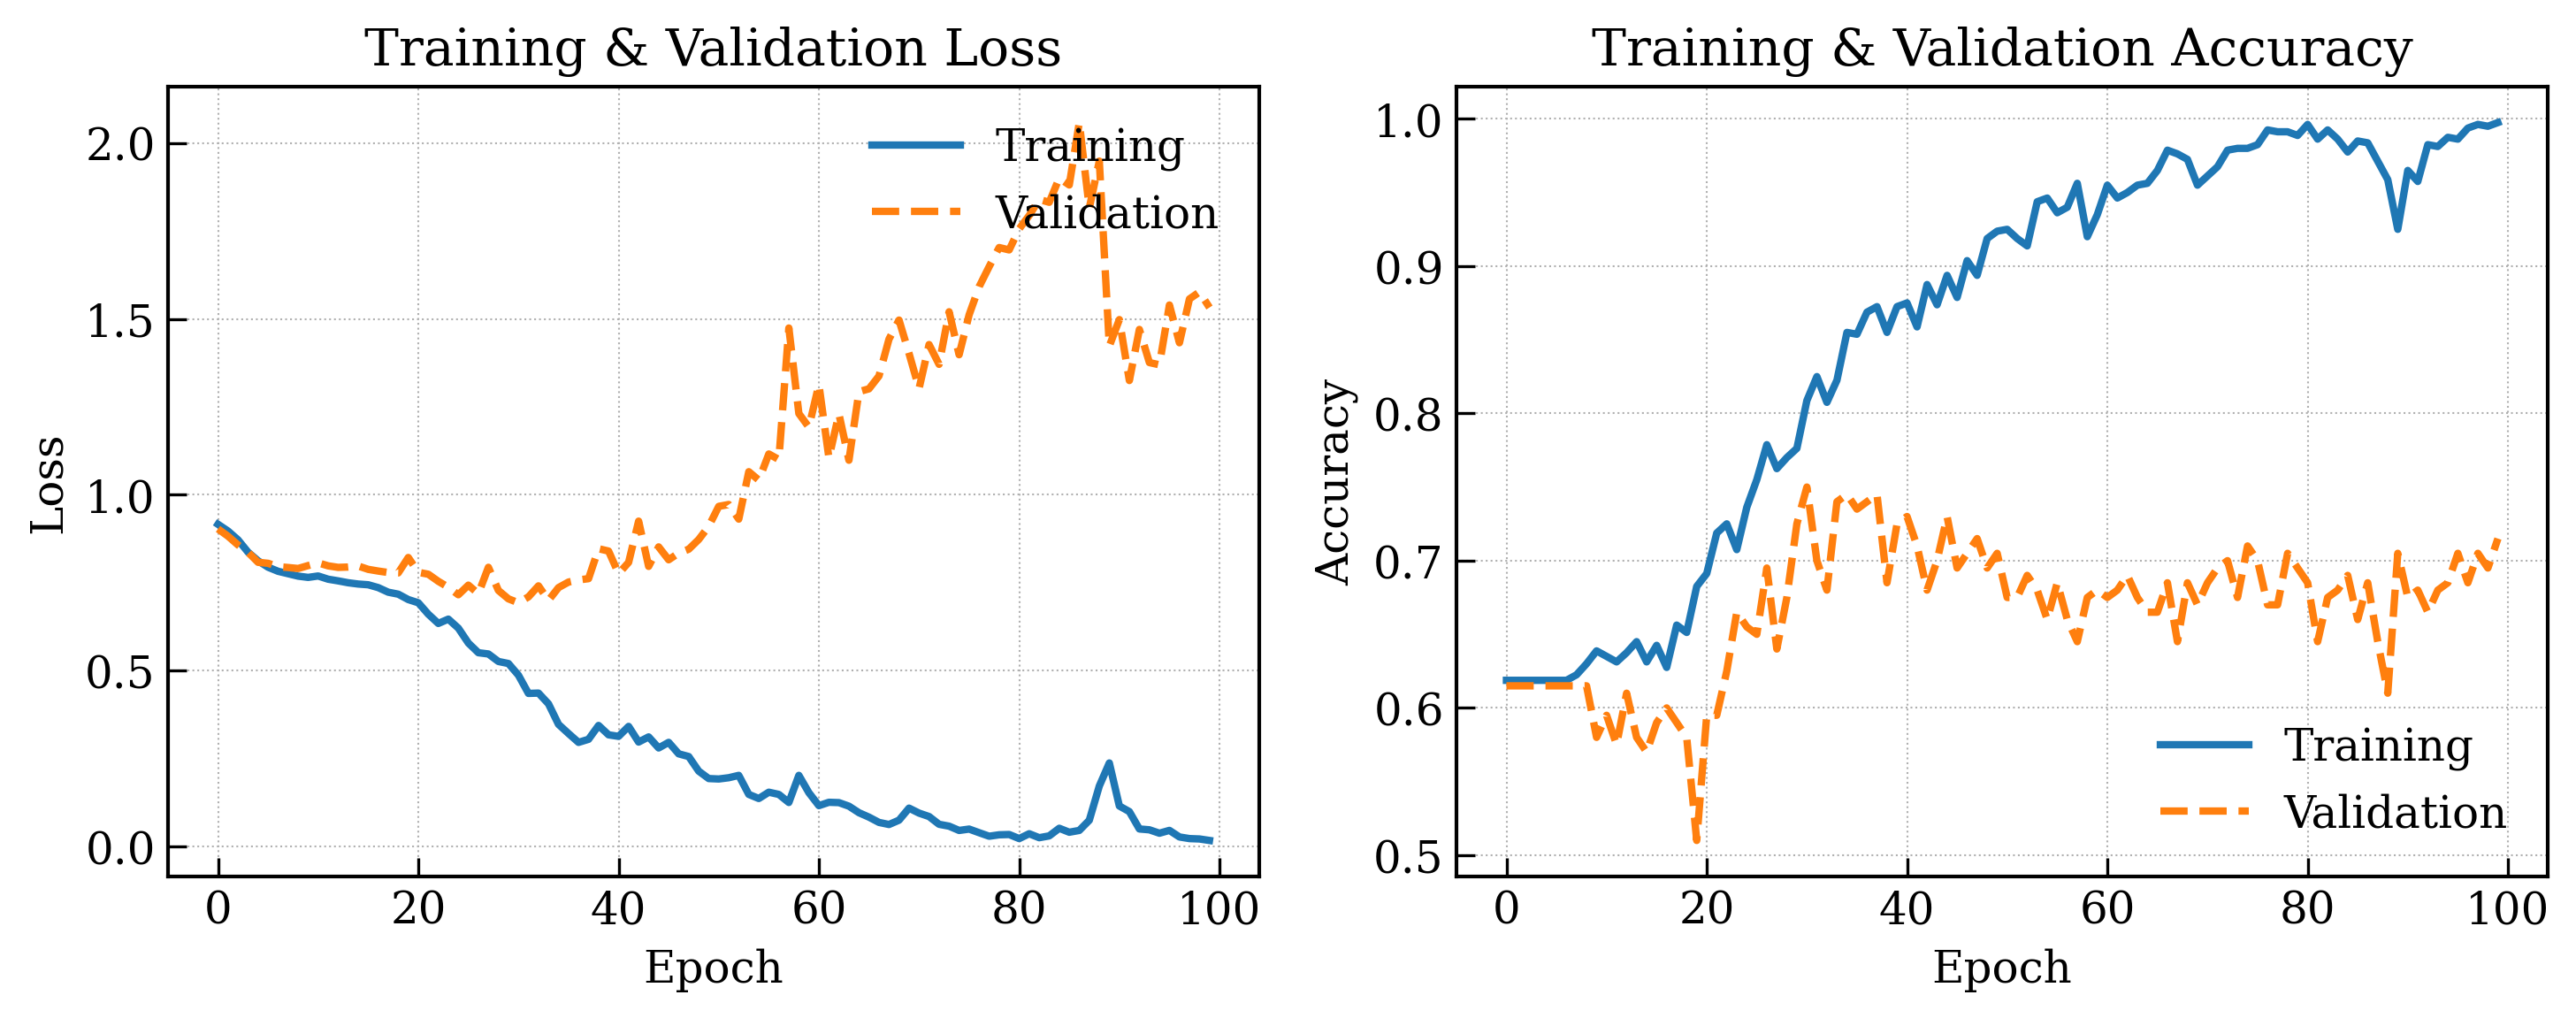

In [16]:
## VISUALIZE TRAINING OUTCOMES (e.g., loss, accuracy, etc.) ##
##############################


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Load your data
losses_train = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/losses_train_epoch_99.npy')
losses_val   = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/losses_val_epoch_99.npy')
preds_train  = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/preds_train_epoch_99.npy')
labels_train = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/labels_train_epoch_99.npy')
preds_val    = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/preds_val_epoch_99.npy')
labels_val   = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/labels_val_epoch_99.npy')

# 2. Compute accuracies per epoch
accuracy_train = np.array([accuracy_score(labels_train[i], preds_train[i])
                           for i in range(len(preds_train))])
accuracy_val   = np.array([accuracy_score(labels_val[i],   preds_val[i])
                           for i in range(len(preds_val))])

# 3. Global styling
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.linewidth': 1.0,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.frameon': False,
    'figure.dpi': 300
})

# 4. Create figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: Loss vs. Epoch ---
ax1.plot(losses_train, label='Training', linewidth=2)
ax1.plot(losses_val,   label='Validation', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.grid(True, linestyle=':', linewidth=0.5)
ax1.legend(loc='upper right')

# --- Right: Accuracy vs. Epoch ---
ax2.plot(accuracy_train, label='Training', linewidth=2)
ax2.plot(accuracy_val,   label='Validation', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.grid(True, linestyle=':', linewidth=0.5)
ax2.legend(loc='lower right')

# 5. Final layout tweaks
fig.tight_layout()

# 6. Save as vector PDF and high-res PNG
fig.savefig('/home/jupyter/repos/lake-vision/sandbox/figure_losses_accuracy.pdf', format='pdf')
fig.savefig('/home/jupyter/repos/lake-vision/sandbox/figure_losses_accuracy.png', dpi=300, format='png')

plt.show()



In [17]:
## ================== ##
## LOAD TRAINED MODEL ##
## ================== ##

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Build your model and wrap it
model = CNN_LSTM_MLP_with_AreaBranch(use_dropout=False, dropout_prob=0.0)
model = nn.DataParallel(model)

missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
model.to(device).eval()

# 2) Load the checkpoint (keys already have 'module.')
state = torch.load("/home/jupyter/repos/lake-vision/sandbox/weights/lstm_drainTYPE_99.pth", map_location=device)
model.load_state_dict(state)

# 3) Move to device & eval
model.to(device).eval()



NameError: name 'state' is not defined

In [18]:
## ========================================================================= ##
## FOR A GIVEN MODEL STATE (WEIGHTS) GET PREDS FOR BOTH SETS (TRAIN AND VAL) ##
## ========================================================================= ##


def predict_with_loader(dl: DataLoader, model: torch.nn.Module, device="cuda"):
    """
    Run model on every item in dl (which must yield
    (img_seq, area_seq, _, _, lakenum) in the same order as ds.ids).
    Returns a numpy array of predicted classes in the same order.
    """
    model.to(device).eval()
    all_preds = []

    with torch.no_grad():
        for img_seq, area, _, _, _ in dl:
            # img_seq: (B, T, C, H, W), area: (B, T, 1)
            img_seq = img_seq.to(device)
            area    = area   .to(device)
            out = model(img_seq, area)           # → (B, num_classes)
            preds = out.argmax(dim=1).cpu().numpy()  # → (B,)
            all_preds.append(preds)

    return np.concatenate(all_preds, axis=0)  # (N_lakes,)

# — after loading your model —
# for inference we want loaders with shuffle=False:
dl_train_inf = DataLoader(
    train_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)
dl_val_inf = DataLoader(
    val_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)

train_preds = predict_with_loader(dl_train_inf, model, device=device)
val_preds   = predict_with_loader(dl_val_inf,   model, device=device)



In [38]:
# assign back into xarray (they line up because shuffle=False)
ds_train_wpreds = ds_train.assign(predicted_draintype=("ids", train_preds))
ds_val_wpreds   = ds_val  .assign(predicted_draintype=("ids", val_preds))

# sanity check
print(ds_train_wpreds.predicted_draintype.values.shape)  # → (n_train,)
print(ds_val_wpreds.  predicted_draintype.values.shape)  # → (n_val,)




(800,)
(200,)


In [41]:
ds_train_wpreds

<xarray.Dataset> Size: 9MB
Dimensions:              (ids: 800, time: 153)
Coordinates:
  * ids                  (ids) object 6kB 'CW2019_2502' ... 'CW2019_1618'
  * time                 (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum              (ids) object 6kB '2019cw_979' ... '2019cw_95'
Data variables: (12/15)
    S1_image_id          (ids, time) object 979kB '' ... 'S1A_IW_GRDH_1SDH_20...
    S1_code              (ids, time) object 979kB '' '25-A-1' ... '' '127-A-3'
    HV_lake              (ids, time) float64 979kB -19.39 -19.39 ... -8.004
    HV_out               (ids, time) float64 979kB -21.23 -21.23 ... -9.469
    S2_water             (ids, time) float64 979kB 0.00657 0.5967 ... 0.02659
    S2_zenith            (ids, time) float64 979kB 56.76 56.2 ... 70.57 70.57
    ...                   ...
    label_Dunmire_raw    (ids) int32 3kB 2 0 3 1 0 0 0 1 1 ... 2 2 3 2 2 1 2 2 1
    date_maxwater_S2     (ids) datetime64[ns] 6kB 2019-06-12 ... 2019-08-04
    date_maxwater_LS     (ids) datetime64[ns] 6kB 2019-07-25 ... 2019-08-04
    label_Rines          (ids) int64 6kB 2 0 0 2 0 2 0 1 2 ... 2 2 0 2 2 2 1 2 0
    label_Dunmire        (ids) int32 3kB 2 0 0 1 0 0 0 1 1 ... 2 2 0 2 2 1 2 2 1
    predicted_draintype  (ids) int64 6kB 2 0 0 2 0 2 0 1 2 ... 2 2 0 2 2 2 1 2 0

labels_Rines    0    1    2
preds                      
0             183    0    1
1               0  122    0
2               0    0  494


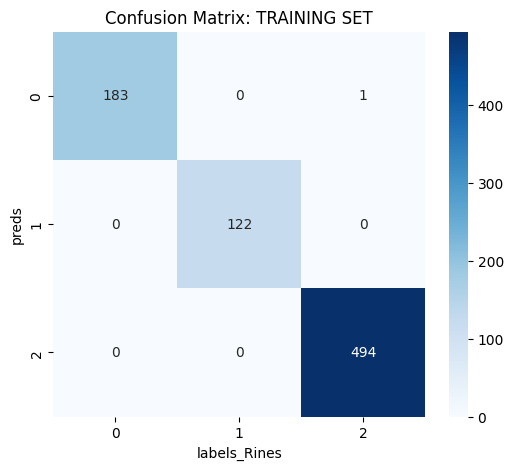

In [44]:

# 2) Pull out the numpy arrays
dun = ds_train_wpreds.predicted_draintype.values
rin = ds_train_wpreds.label_Rines.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Rines'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: TRAINING SET")
plt.show()


labels_Dunmire    0    1    2
preds                        
0               171    8    5
1                 8   97   17
2                79  123  292


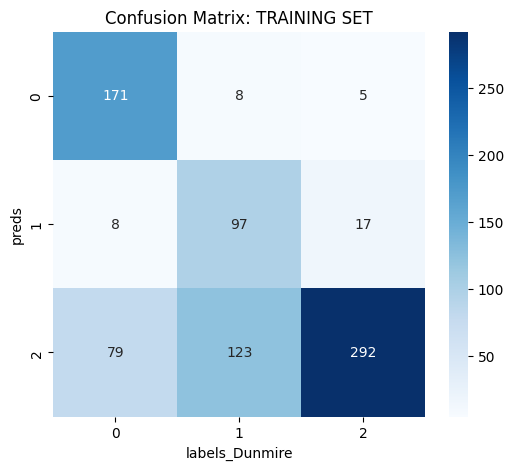

In [48]:

# 2) Pull out the numpy arrays
dun = ds_train_wpreds.predicted_draintype.values
rin = ds_train_wpreds.label_Dunmire.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Dunmire'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: TRAINING SET")
plt.show()



labels_Rines   0   1   2
preds                   
0             33   1  17
1              0  14  10
2             18  11  96


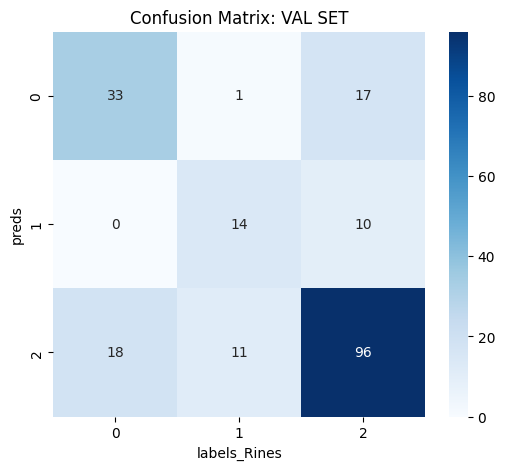

In [45]:

# 2) Pull out the numpy arrays
dun = ds_val_wpreds.predicted_draintype.values
rin = ds_val_wpreds.label_Rines.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Rines'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: VAL SET")
plt.show()


labels_Dunmire   0   1   2
preds                     
0               37   2  12
1                1  20   3
2               32  35  58


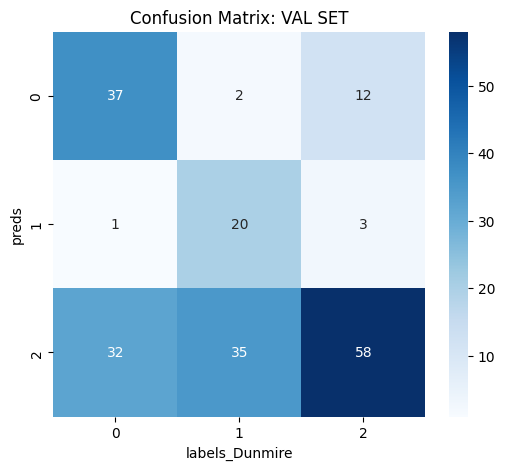

In [47]:

# 2) Pull out the numpy arrays
dun = ds_val_wpreds.predicted_draintype.values
rin = ds_val_wpreds.label_Dunmire.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Dunmire'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: VAL SET")
plt.show()


In [50]:
# 1) Flatten your xarray into a DataFrame
df = pd.DataFrame({
    'lakenum':           ds_val_wpreds.lakenum.values,
    'label_Dunmire':     ds_val_wpreds.label_Dunmire.values,
    'label_Rines':       ds_val_wpreds.label_Rines.values,
    'predicted_Rines':   ds_val_wpreds.predicted_draintype.values
})

# 2) Case 1: Dunmire=1 but model predicts 2 (and Rines=2)
mask1 = (
    (df['label_Dunmire']   == 1) &
    (df['label_Rines']     == 2) &
    (df['predicted_Rines'] == 2)
)
df_case1 = df[mask1]

# 3) Case 2: Dunmire=2 but model predicts 1 (and Rines=1)
mask2 = (
    (df['label_Dunmire']   == 2) &
    (df['label_Rines']     == 1) &
    (df['predicted_Rines'] == 1)
)
df_case2 = df[mask2]

# 4) Inspect
print(f"Case 1 (Dun=1 → Pred=2): {len(df_case1)} lakes")
display(df_case1)

print(f"Case 2 (Dun=2 → Pred=1): {len(df_case2)} lakes")
display(df_case2)


Case 1 (Dun=1 → Pred=2): 25 lakes


,lakenum,label_Dunmire,label_Rines,predicted_Rines
0,2019cw_561,1,2,2
11,2019cw_33,1,2,2
28,2019cw_371,1,2,2
30,2019cw_451,1,2,2
39,2019cw_397,1,2,2
44,2019cw_106,1,2,2
59,2019cw_484,1,2,2
61,2019cw_598,1,2,2
64,2019cw_443,1,2,2
68,2019cw_333,1,2,2


Case 2 (Dun=2 → Pred=1): 2 lakes


,lakenum,label_Dunmire,label_Rines,predicted_Rines
35,2019cw_268,2,1,1
65,2019cw_894,2,1,1
